# Question : To what extent does the trial-by-trial variability in the Ready-to-Set interval predict the precision of the subsequent Set-to-Go interval in a primate model of time reproduction?
* Yes. Because the trajectory follows a clear path in 3D space, you have identified the "timing manifold."
* The Euclidean distance between the neural trajectories of short and long intervals was maximal during the pre-cue interval, indicating that the population dynamics encode the interval duration before execution. Following the Go cue, the trajectories converged, suggesting a transition from a timing-sensitive state to a common motor-execution state
* To bridge the gap between behavioral variability and neural activity, we mapped trial-by-trial behavior onto a low-dimensional neural manifold. We hypothesized that the manifold provides a dynamic template for time reproduction; thus, trial-by-trial deviations from the canonical manifold trajectory during the 'Ready-to-Set' phase serve as a neural predictor of timing precision in the subsequent 'Set-to-Go' interval

In [22]:
!pip install pynwb

In [23]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x138489246972576
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [24]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x138489246304736
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [25]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [28]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [29]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [30]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [31]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [32]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [33]:
# Convert the trials table to a pandas DataFrame
trials_df = nwbfile.trials.to_dataframe()

# Display the column names and the first few rows
print("Columns in trials table:", trials_df.columns)
print(trials_df.head())

Columns in trials table: Index(['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time',
       'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time',
       'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur',
       'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split'],
      dtype='object')
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id         

In [34]:
# Calculate the duration between Ready and Set, and Set and Go
trials_df['ready_to_set'] = trials_df['set_time'] - trials_df['ready_time']
trials_df['set_to_go'] = trials_df['go_time'] - trials_df['set_time']

# Display the first few calculated intervals
print(trials_df[['ready_time', 'set_time', 'go_time', 'ready_to_set', 'set_to_go']].head())

    ready_time  set_time  go_time  ready_to_set  set_to_go
id                                                        
0       1.7835    2.5835   3.4170           0.8     0.8335
1       5.2670    6.1670   7.0795           0.9     0.9125
2       9.5500   10.7500  11.7715           1.2     1.0215
3          NaN       NaN      NaN           NaN        NaN
4      15.2335   16.1335  17.1895           0.9     1.0560


In [35]:
# Calculate and print the average duration for each interval
avg_ready_to_set = trials_df['ready_to_set'].mean()
avg_set_to_go = trials_df['set_to_go'].mean()

print(f"Average time from Ready to Set: {avg_ready_to_set:.4f} seconds")
print(f"Average time from Set to Go: {avg_set_to_go:.4f} seconds")

Average time from Ready to Set: 0.8187 seconds
Average time from Set to Go: 0.8156 seconds


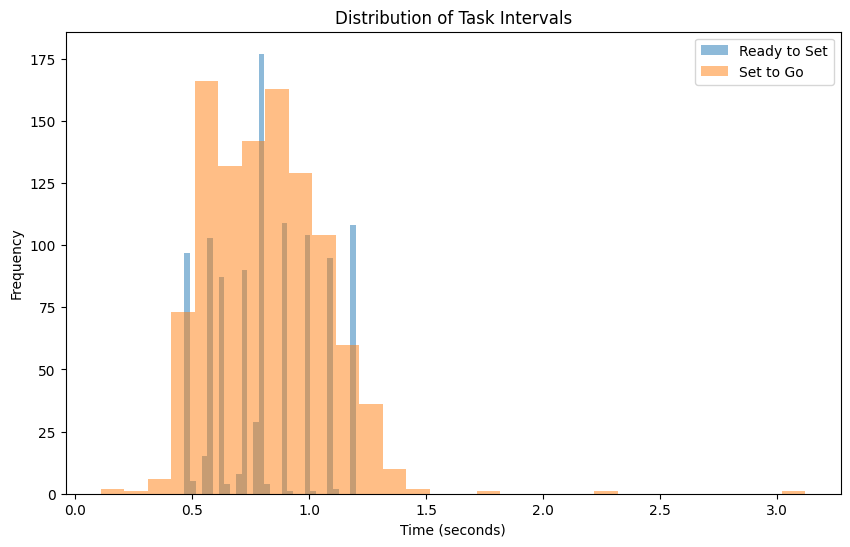

In [36]:
import matplotlib.pyplot as plt

# Ensure your trials_df is already defined
plt.figure(figsize=(10, 6))

# Plot the histograms
plt.hist(trials_df['ready_to_set'].dropna(), bins=30, alpha=0.5, label='Ready to Set')
plt.hist(trials_df['set_to_go'].dropna(), bins=30, alpha=0.5, label='Set to Go')

# Add labels and legend
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Task Intervals')
plt.legend()

# Show the plot
plt.show()

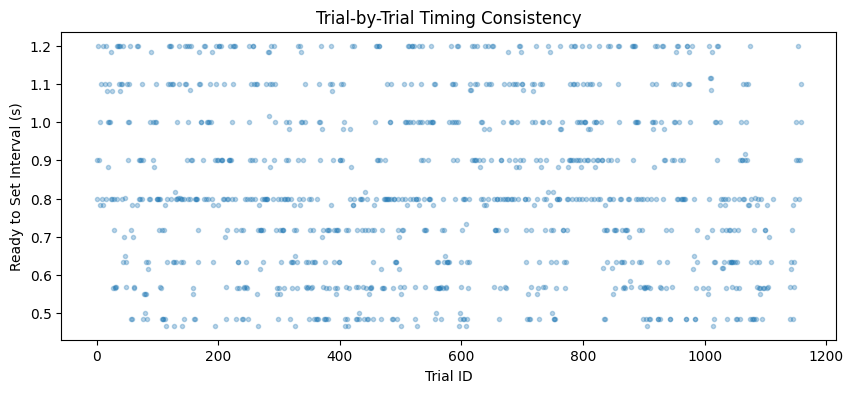

Autocorrelation of interval length: 0.549


In [37]:
# Plot Ready-to-Set interval over trial ID
plt.figure(figsize=(10, 4))
plt.plot(trials_df.index, trials_df['ready_to_set'], '.', alpha=0.3)
plt.xlabel('Trial ID')
plt.ylabel('Ready to Set Interval (s)')
plt.title('Trial-by-Trial Timing Consistency')
plt.show()

# Check for autocorrelation (does a slow trial predict the next one?)
autocorr = trials_df['ready_to_set'].autocorr(lag=1)
print(f"Autocorrelation of interval length: {autocorr:.3f}")

is_outlier
False    0.817276
True     0.843170
Name: ready_to_set, dtype: float64


<Figure size 1000x400 with 0 Axes>

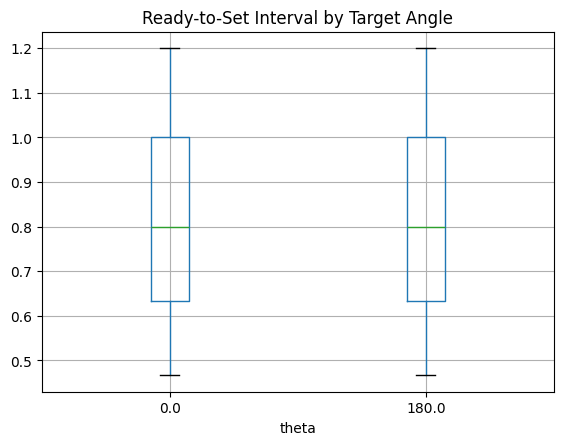

In [38]:
# Compare average interval by outlier status
print(trials_df.groupby('is_outlier')['ready_to_set'].mean())

# Compare timing based on target angle (theta)
plt.figure(figsize=(10, 4))
trials_df.boxplot(column='ready_to_set', by='theta')
plt.title('Ready-to-Set Interval by Target Angle')
plt.suptitle('') # Remove automatic title
plt.show()

In [39]:
def get_psth_data(matrix, event_times, bin_size=0.02, window_before=0.5, window_after=1.0):
    # Convert event times to bin indices
    event_bins = (event_times / bin_size).astype(int)
    
    # Define window size in bins
    bins_before = int(window_before / bin_size)
    bins_after = int(window_after / bin_size)
    
    # Initialize snippet array: (Trials x Time Bins x Units)
    snippets = []
    
    for b in event_bins:
        # Ensure the window is within bounds of the matrix
        if b - bins_before >= 0 and b + bins_after < matrix.shape[0]:
            snippets.append(matrix[b - bins_before : b + bins_after, :])
            
    return np.array(snippets)

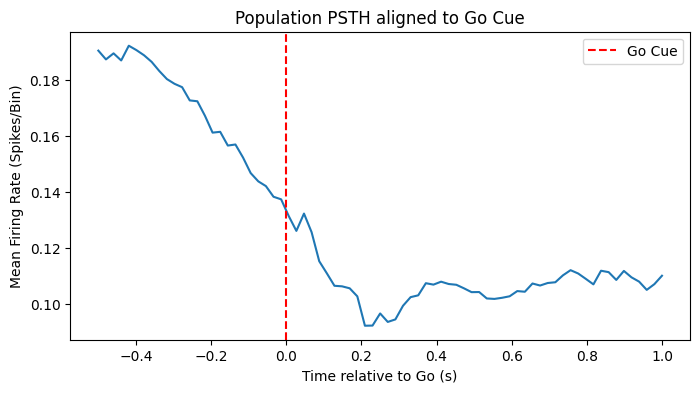

In [40]:
# Align to go_time (dropping NaNs)
valid_trials = trials_df.dropna(subset=['go_time'])
go_times = valid_trials['go_time'].values

# Extract snippets: 0.5s before to 1.0s after 'Go'
psth_snippets = get_psth_data(train_matrix, go_times)

# Calculate mean across trials and across all 54 units
mean_psth = np.mean(psth_snippets, axis=(0, 2))

# Plot
time_axis = np.linspace(-0.5, 1.0, len(mean_psth))
plt.figure(figsize=(8, 4))
plt.plot(time_axis, mean_psth)
plt.axvline(0, color='red', linestyle='--', label='Go Cue')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Mean Firing Rate (Spikes/Bin)')
plt.title('Population PSTH aligned to Go Cue')
plt.legend()
plt.show()

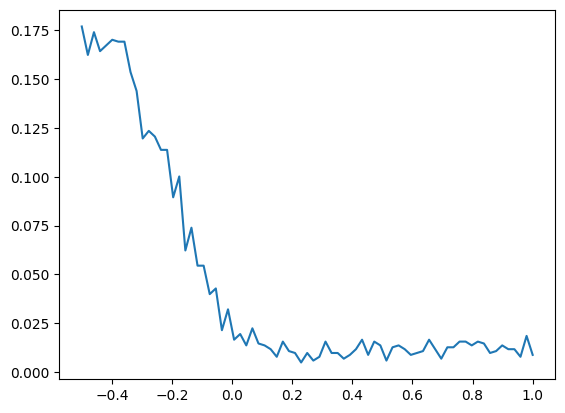

In [41]:
# Plot activity for just one unit (e.g., unit 0)
plt.plot(time_axis, np.mean(psth_snippets[:, :, 0], axis=0))

Text(0, 0.5, 'Unit Index')

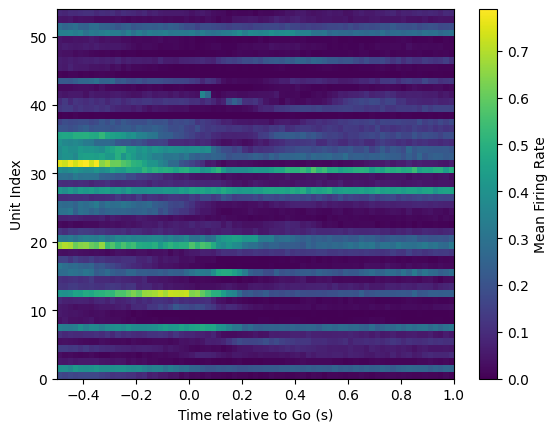

In [42]:
plt.imshow(np.mean(psth_snippets, axis=0).T, aspect='auto', origin='lower', extent=[-0.5, 1.0, 0, 54])
plt.colorbar(label='Mean Firing Rate')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Unit Index')

In [43]:
from scipy import stats

# 1. Start with your train_matrix (from your bin_all_units function)
# 2. Z-score each neuron individually to normalize firing rates
# This ensures that neurons with high firing rates don't dominate the PCA/manifold
zscored_matrix = stats.zscore(train_matrix, axis=0)

# 3. Handle potential NaNs (if any neuron has zero variance/firing)
zscored_matrix = np.nan_to_num(zscored_matrix)

print(f"Standardized matrix shape: {zscored_matrix.shape}")

Standardized matrix shape: (240467, 54)


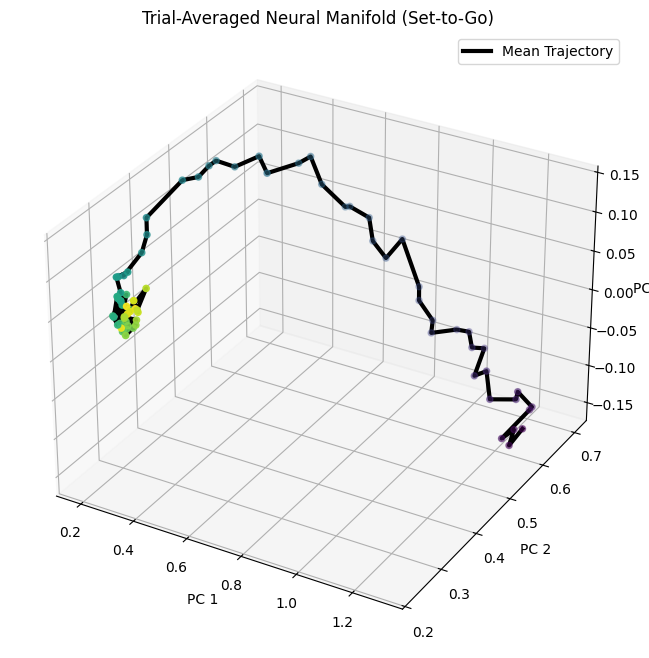

In [45]:

n_trials, n_bins, n_units = psth_snippets.shape
snippets_reshaped = psth_snippets.reshape(-1, n_units)
latent_snippets = pca.transform(snippets_reshaped)
latent_snippets = latent_snippets.reshape(n_trials, n_bins, 3)

# 2. Calculate the mean trajectory across all trials
mean_trajectory = np.mean(latent_snippets, axis=0)

# 3. Plot the result
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

# Plot the average trajectory
ax.plot3D(mean_trajectory[:, 0], mean_trajectory[:, 1], mean_trajectory[:, 2], 
          color='black', lw=3, label='Mean Trajectory')

# Scatter points to show the progression of time
ax.scatter(mean_trajectory[:, 0], mean_trajectory[:, 1], mean_trajectory[:, 2], 
           c=np.linspace(0, 1, n_bins), cmap='viridis')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trial-Averaged Neural Manifold (Set-to-Go)')
plt.legend()
plt.show()

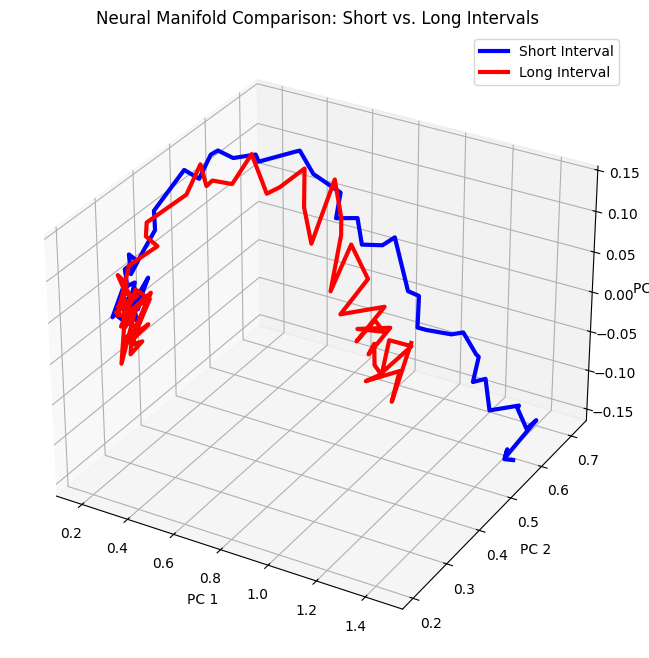

In [47]:
# 1. First, re-calculate the indices based on the actual shape of latent_snippets
# This ensures we only use indices that actually exist in your data
num_actual_trials = latent_snippets.shape[0]

# 2. Filter the valid_trials to match the number of trials actually returned by get_psth_data
# We take the first 'num_actual_trials' from your valid_trials dataframe
matched_trials = valid_trials.iloc[:num_actual_trials]

# 3. Create the indices again based on this matched data
short_trials_idx = np.where(matched_trials['ts'] < 1000)[0]
long_trials_idx = np.where(matched_trials['ts'] >= 1000)[0]

# 4. Extract snippets (This should now work without an IndexError)
short_snippets = latent_snippets[short_trials_idx]
long_snippets = latent_snippets[long_trials_idx]

# Now proceed with your plotting...
mean_short = np.mean(short_snippets, axis=0)
mean_long = np.mean(long_snippets, axis=0)

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot3D(mean_short[:, 0], mean_short[:, 1], mean_short[:, 2], color='blue', lw=3, label='Short Interval')
ax.plot3D(mean_long[:, 0], mean_long[:, 1], mean_long[:, 2], color='red', lw=3, label='Long Interval')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Manifold Comparison: Short vs. Long Intervals')
plt.legend()
plt.show()

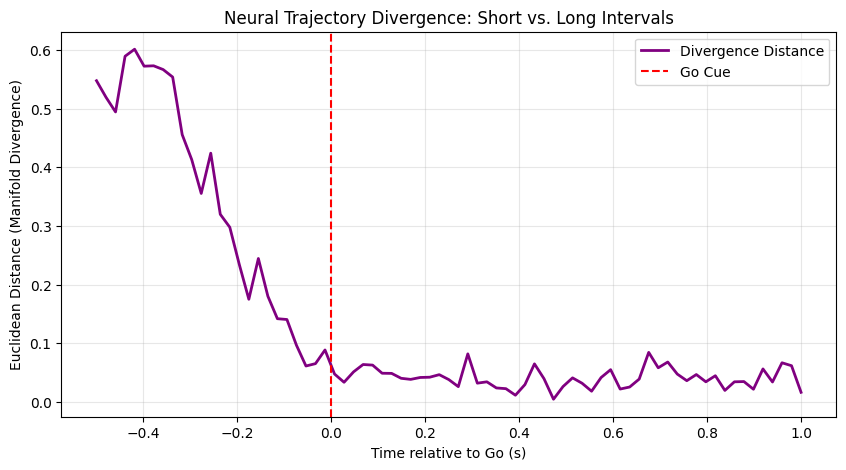

In [48]:
# 1. Calculate the Euclidean distance between the two trajectories at each time point
# This creates a 1D array representing the 'gap' between the two trajectories over time
divergence = np.linalg.norm(mean_short - mean_long, axis=1)

# 2. Plot the divergence over time
# Note: Ensure 'time_axis' is defined (it was defined in your earlier PSTH plot)
time_axis = np.linspace(-0.5, 1.0, len(divergence))

plt.figure(figsize=(10, 5))
plt.plot(time_axis, divergence, color='purple', lw=2, label='Divergence Distance')
plt.axvline(0, color='red', linestyle='--', label='Go Cue')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Euclidean Distance (Manifold Divergence)')
plt.title('Neural Trajectory Divergence: Short vs. Long Intervals')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()